In [2]:
from pathlib import Path

path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training.h5")

print(path.exists())
print(path.stat().st_size / 1024**2, "MB")

True
255.2816619873047 MB


In [4]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']


In [ ]:
with h5py.File(path, "r") as f:
    print("X:", f["X"].shape)
    print("X_err:", f["X_err"].shape)
    print("y:", f["y"].shape)
    print("gaia wavelengths:", f["gaia_wavelength_nm"].shape)
    print("sdss wavelengths:", f["sdss_wavelength_aa"].shape)

X: (15598, 343)
X_err: (15598, 343)
y: (15598, 3600)
gaia wavelengths: (343,)
sdss wavelengths: (3600,)


In [22]:
import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    X_err = f["X_err"][:]
    y = f["y"][:]

    gaia_wavelength = f["gaia_wavelength_nm"][:]
    sdss_wavelength = f["sdss_wavelength_aa"][:]

print(X.shape)
print(y.shape)

(15598, 343)
(15598, 3600)


In [ ]:
# Nos quedamos solo con el intervalo comun de ambos datos 
gaia_mask = (gaia_wavelength >= 450) & (gaia_wavelength <= 900)
sdss_mask = (sdss_wavelength >= 4500) & (sdss_wavelength <= 9000)

X = X[:, gaia_mask]
X_err = X_err[:, gaia_mask]
y = y[:, sdss_mask]

print(X.shape)
print(y.shape)

IndexError: boolean index did not match indexed array along dimension 1; dimension is 226 but corresponding boolean dimension is 343

In [31]:

gaia_wavelength = gaia_wavelength[gaia_mask]
sdss_wavelength = sdss_wavelength[sdss_mask]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23
)

# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(1024, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(1024, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(2048, activation="relu"),
    layers.BatchNormalization(),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 512)            │       116,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2999)           │     6,144,951 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,953,719 (37.97 MB)

 Trainable params: 9,944,503 (37.94 MB)

 Non-trainable params: 9,216 (36.00 KB)

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_norm,
    y_train_norm,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - loss: 0.6407 - mae: 0.4201 - mse: 0.6407 - val_loss: 0.4590 - val_mae: 0.3144 - val_mse: 0.4590
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 0.4026 - mae: 0.2447 - mse: 0.4026 - val_loss: 0.5305 - val_mae: 0.2841 - val_mse: 0.5305
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.4414 - mae: 0.2777 - mse: 0.4414 - val_loss: 0.2885 - val_mae: 0.2176 - val_mse: 0.2885
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - loss: 0.4376 - mae: 0.2406 - mse: 0.4376 - val_loss: 0.2578 - val_mae: 0.1653 - val_mse: 0.2578
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.2651 - mae: 0.2023 - mse: 0.2651 - val_loss: 0.3497 - val_mae: 0.1829 - val_mse: 0.3497
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - loss: 0.3118 - mae: 0.2241 - mse: 0.3118 - val_loss: 0.4792 - val_mae: 0.2705 - val_mse: 0.4792
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - loss: 0.3448 - mae: 0.2245 - mse

In [28]:
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


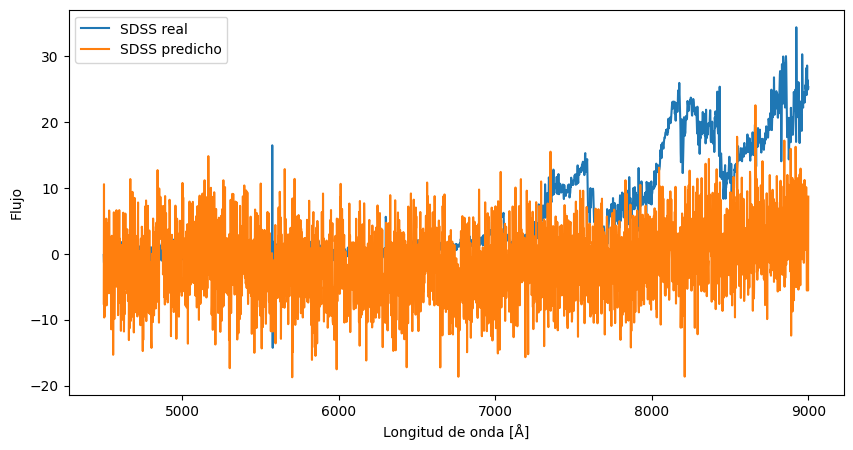

In [32]:
import matplotlib.pyplot as plt

i = 0

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()